In [1]:
import pandas as pd
import numpy as np

In [5]:
X_train = np.array([[1,2],[2,3],[3,3],[6,5],[7,7]])
y_train= np.array([0,0,0,1,1])
X_test = np.array([[2,2],[6,6]])


In [6]:
## Visualize

X_train_df= pd.DataFrame(X_train, columns = ["X1","X2"])
X_test_df= pd.DataFrame(X_test, columns = ["X1","X2"])

In [7]:
X_train_df.head()

,X1,X2
0,1,2
1,2,3
2,3,3
3,6,5
4,7,7


In [9]:
X_test_df.head()

,X1,X2
0,2,2
1,6,6


<Axes: xlabel='X1', ylabel='X2'>

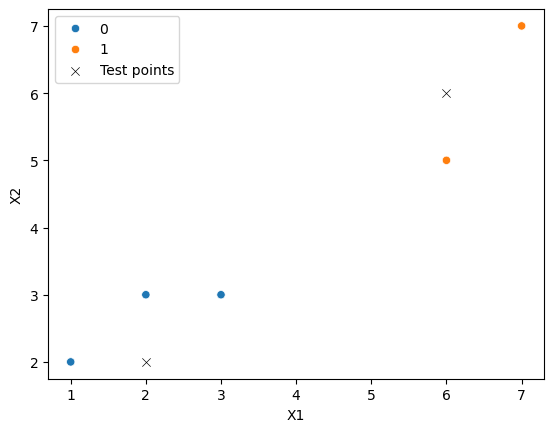

In [12]:
import seaborn as sns
X_train_df["label"] = y_train
sns.scatterplot(data=X_train_df,x = "X1", y = "X2", hue = "label")
sns.scatterplot(data=X_test_df,x = "X1", y = "X2",marker = "x", color = "black", label = "Test points")

In [22]:
class KNNClassifier:
    def __init__(self,k):
        self.k = k

    def fit(self,X,y):
        self.X_train = X
        self.y_train = y
    
    def distance(self,x1,x2):
        return np.sqrt(np.sum((x1-x2)**2))

    def predict_one(self,X):
        distances = [self.distance(X,x_train) for x_train in self.X_train]
        knn_indices = np.argsort(distances)[:self.k]
        knn_classes = [self.y_train[i] for i in knn_indices]
        majority_class = np.argmax(np.bincount(knn_classes))
        return majority_class
    def predict(self,X):
        y_pred = [self.predict_one(i) for i in X]
        return np.array(y_pred)

In [24]:
knn = KNNClassifier(k = 3)
knn.fit(X_train,y_train)
knn.predict(X_test)

array([0, 1])